In [ ]:
!unzip -q auta.zip -d dataset/

replace dataset/Volkswagen/Volkswagen_000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

🚀 INICJALIZACJA STRUMIENIA DANYCH (Zero RAM Error)...
Found 4597 files belonging to 50 classes.
Using 3678 files for training.
Found 4597 files belonging to 50 classes.
Using 919 files for validation.
✅ Znaleziono klas: 50

🛠️ Budowa modelu MobileNetV2...

🔥 START TRENIGU (Model działa na taśmociągu) 🔥
Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 68s 371ms/step - accuracy: 0.0299 - loss: 5.2040 - val_accuracy: 0.0555 - val_loss: 3.8265
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.0715 - loss: 4.5274 - val_accuracy: 0.1001 - val_loss: 3.6988
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.1090 - loss: 4.0735 - val_accuracy: 0.1262 - val_loss: 3.5790
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.1476 - loss: 3.7327 - val_accuracy: 0.1621 - val_loss: 3.5332
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.1860 - loss: 3.4602 - val_accuracy: 0.1643 - val_loss: 3.5031
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/s

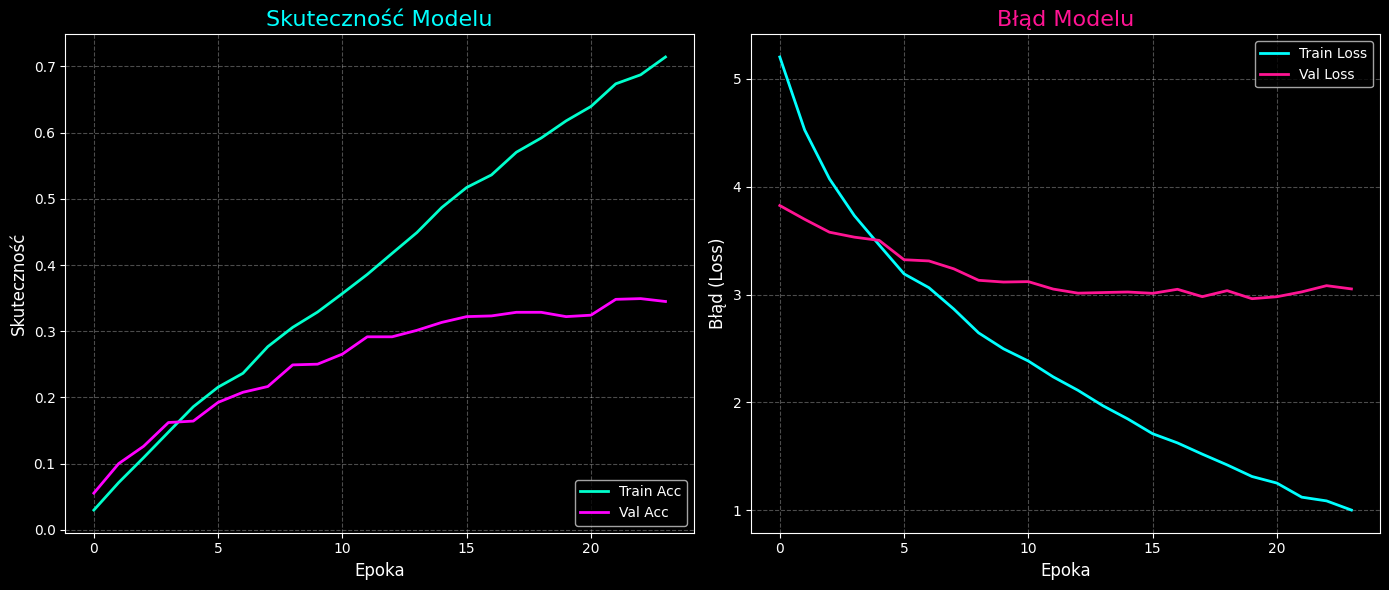

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

print(" INICJALIZACJA STRUMIENIA DANYCH.")

data_dir = 'dataset'
batch_size = 32
img_size = (224, 224)

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=42,
  image_size=img_size,
  batch_size=batch_size,
  label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=42,
  image_size=img_size,
  batch_size=batch_size,
  label_mode='categorical'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f" Znaleziono klas: {num_classes}")

AUTOTUNE = tf.data.AUTOTUNE
def process(image, label):
    return preprocess_input(image), label

train_ds = train_ds.map(process).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(process).cache().prefetch(buffer_size=AUTOTUNE)


print("\n🛠️ Budowa modelu MobileNetV2...")
inputs = Input(shape=(224, 224, 3))
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n START TRENIGU ")
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

print("\n Test końcowy...")
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
print(f" Ostateczna skuteczność na nowych zdjęciach: {val_acc*100:.2f}%")

plt.style.use('dark_background')
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(history_fine.history['accuracy'], label='Train Acc', color='#00FFCC', linewidth=2)
plt.plot(history_fine.history['val_accuracy'], label='Val Acc', color='#FF00FF', linewidth=2)
plt.title('Skuteczność Modelu', fontsize=16, color='#00FFFF')
plt.xlabel('Epoka', fontsize=12, color='white')
plt.ylabel('Skuteczność', fontsize=12, color='white')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_fine.history['loss'], label='Train Loss', color='#00FFFF', linewidth=2)
plt.plot(history_fine.history['val_loss'], label='Val Loss', color='#FF1493', linewidth=2)
plt.title('Błąd Modelu', fontsize=16, color='#FF1493')
plt.xlabel('Epoka', fontsize=12, color='white')
plt.ylabel('Błąd (Loss)', fontsize=12, color='white')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()